In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv('/content/FinalDataset - Sheet1.csv')

print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())

             Q1          Q2                       Q3          Q4  \
0  Several days  Not at all  More than half the days  Not at all   
1  Several days  Not at all  More than half the days  Not at all   
2  Several days  Not at all  More than half the days  Not at all   
3  Several days  Not at all  More than half the days  Not at all   
4  Several days  Not at all  More than half the days  Not at all   

                        Q5                       Q6                       Q7  \
0         Nearly every day  More than half the days             Several days   
1         Nearly every day  More than half the days             Several days   
2         Nearly every day  More than half the days             Several days   
3         Nearly every day  More than half the days             Several days   
4  More than half the days  More than half the days  More than half the days   

                 Q8                       Q9           Q10  \
0      Several days  More than half the days    

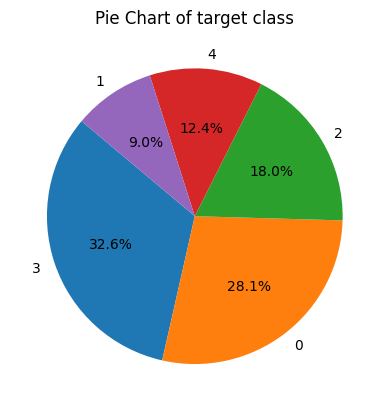

In [ ]:
import matplotlib.pyplot as plt
# Count values for each category
category_counts = data['Disease'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of target class')
plt.show()

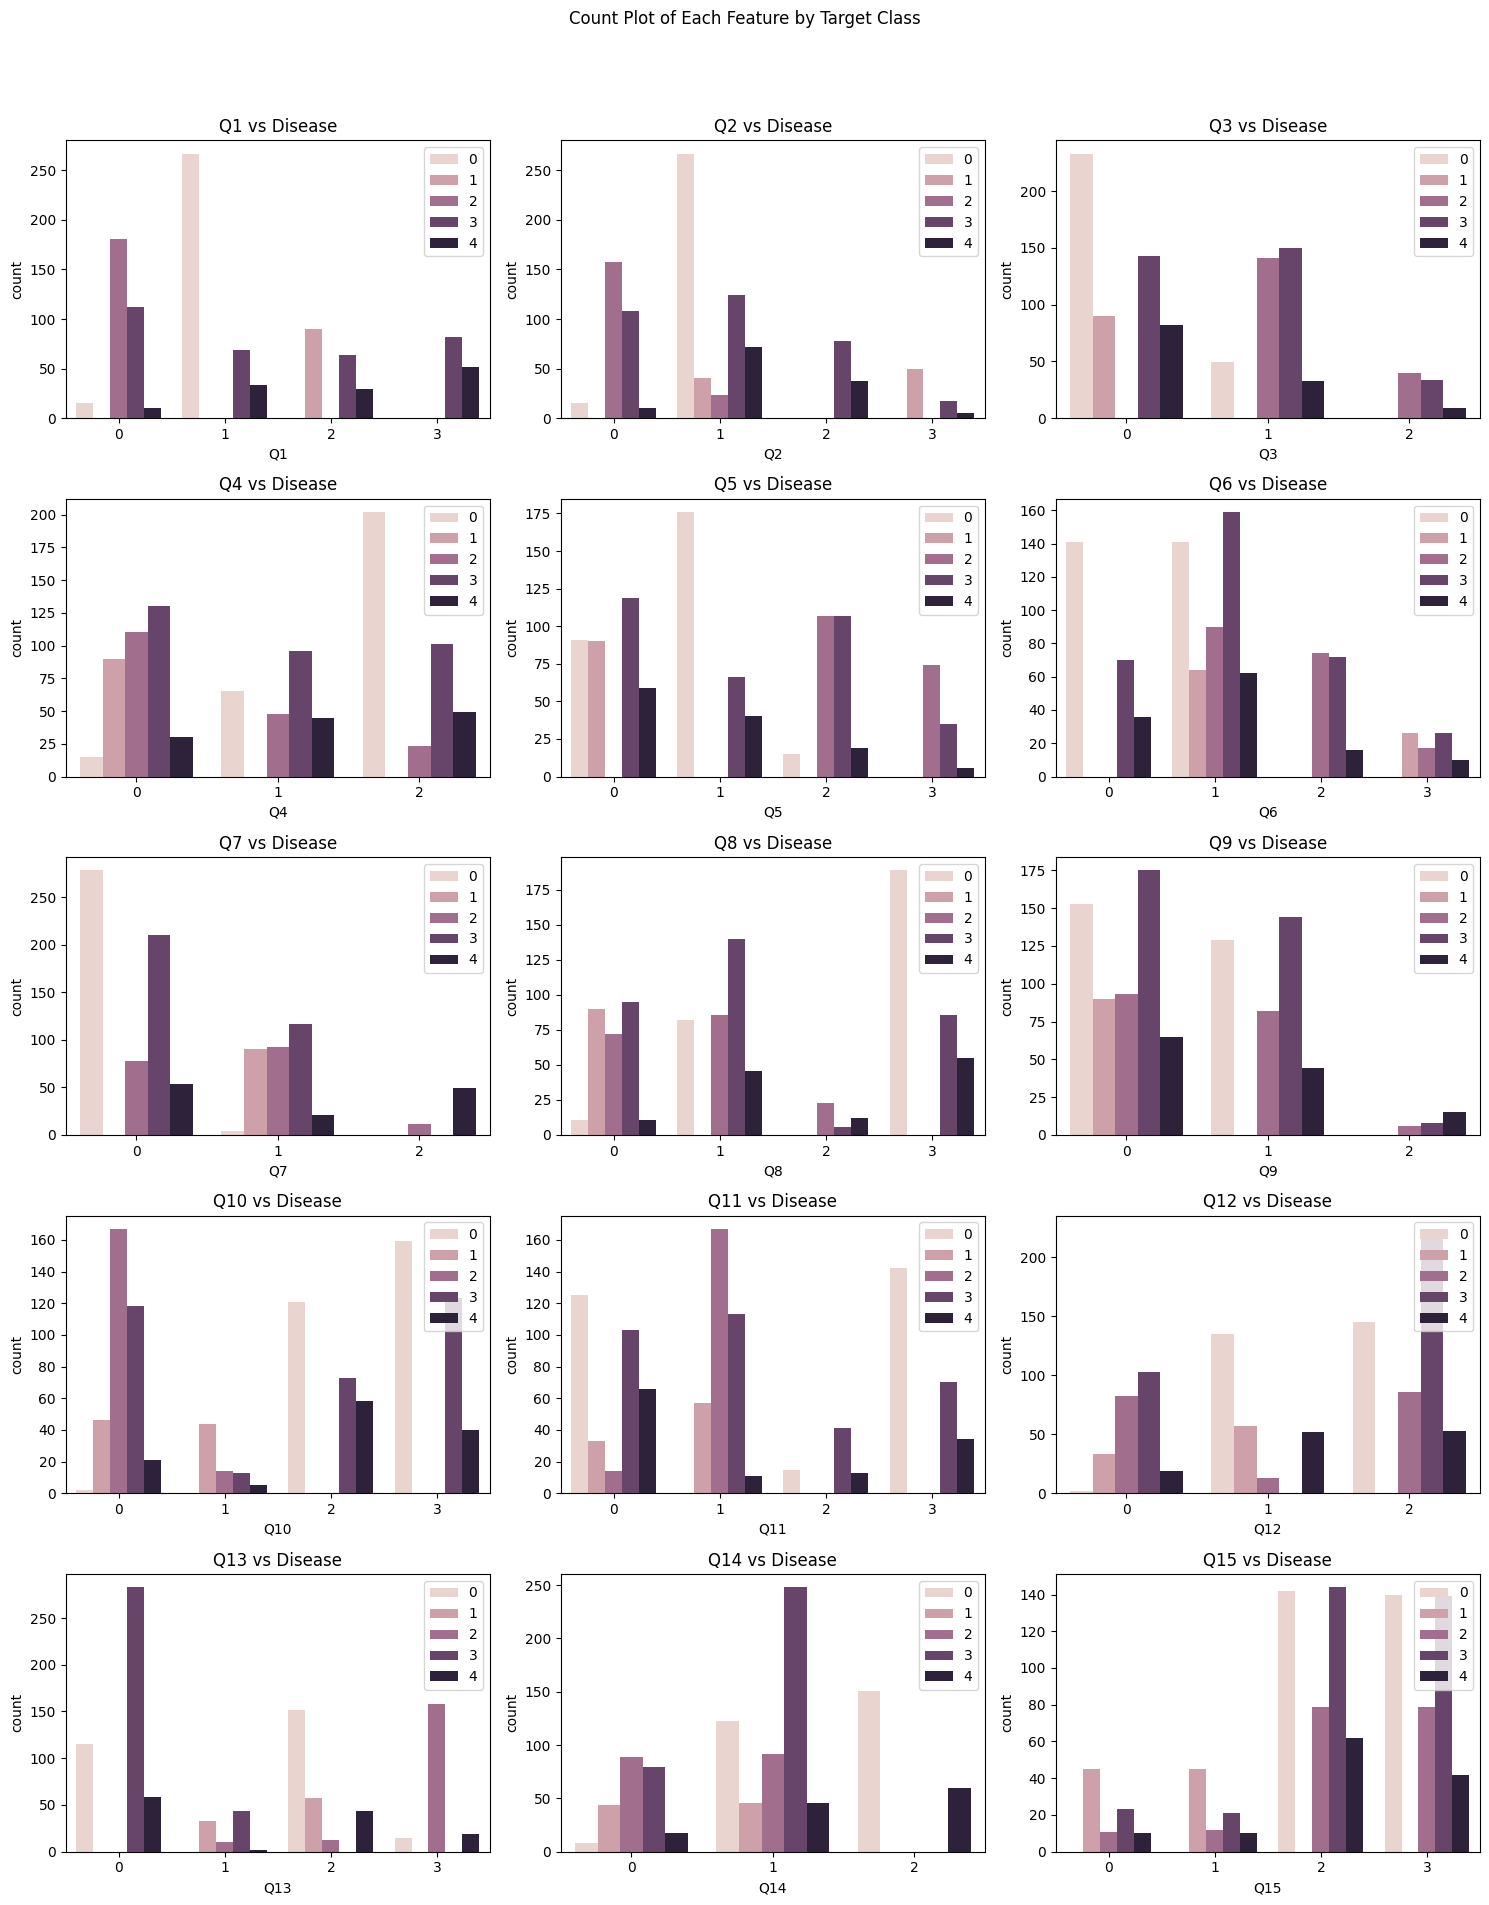

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.suptitle("Count Plot of Each Feature by Target Class")

for i, col in enumerate(data.columns[:-1]):
    sns.countplot(x=col, hue='Disease', data=data, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} vs Disease')
    axes[i//3, i%3].legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


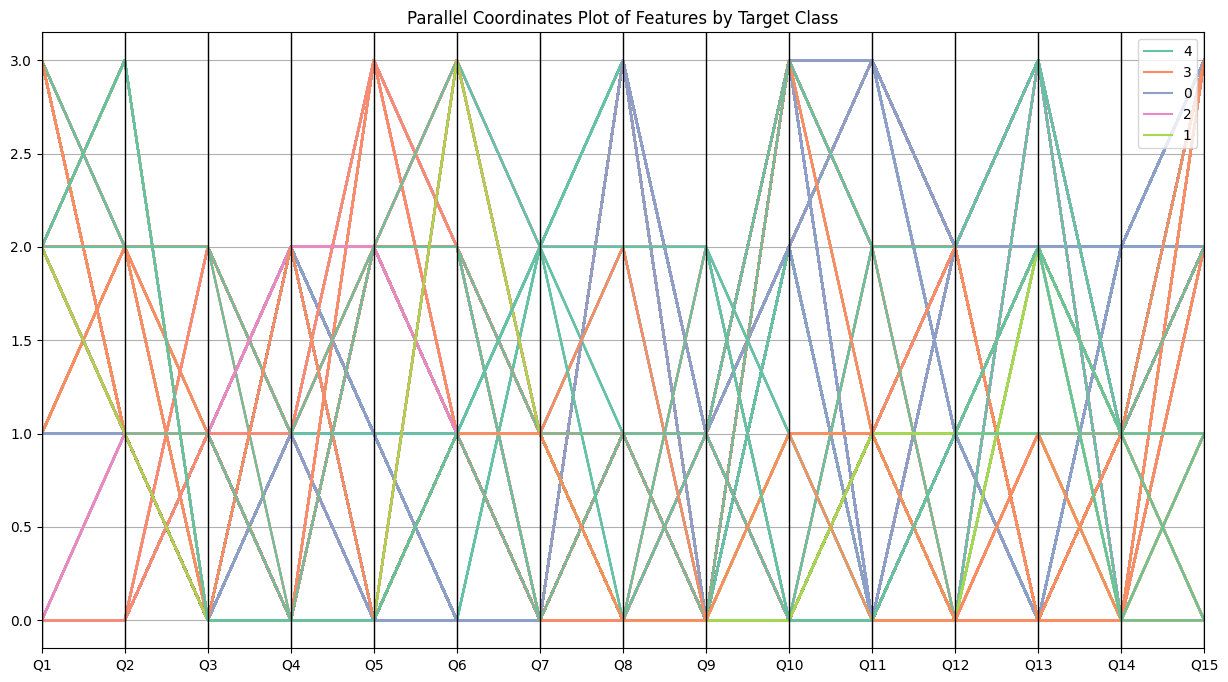

In [ ]:
from pandas.plotting import parallel_coordinates

# Encode features as ordinal for parallel coordinates plot
encoded_data = data.copy()
for col in encoded_data.columns[:-1]:
    encoded_data[col] = encoded_data[col].astype('category').cat.codes

plt.figure(figsize=(15, 8))
parallel_coordinates(encoded_data, 'Disease', color=sns.color_palette("Set2", 5))
plt.title('Parallel Coordinates Plot of Features by Target Class')
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])


X = data.iloc[:, :-1].values
y = data.iloc[:, -1:].values

# Split the data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)


multi_target_rf = MultiOutputClassifier(rf_classifier, n_jobs=-1)

multi_target_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = multi_target_rf.predict(X_test)
scores = cross_val_score(rf_classifier, X_train, y_train, cv=3)
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Cross-Validation Accuracy:", scores.mean())
# Evaluate the model's performance for each label
for i in range(y_test.shape[1]):
    print(f"Label {i+1} Accuracy: {accuracy_score(y_test[:, i], y_pred[:, i]) * 100:.2f}%")
    print(f"Classification Report for Label {i+1}:")
    print(classification_report(y_test[:, i], y_pred[:, i]))


average_accuracy = (accuracy_score(y_test, y_pred) * 100)
print(f"Overall Accuracy: {average_accuracy:.2f}%")


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Cross-Validation Accuracy Scores: [0.98290598 0.98717949 0.9957265 ]
Mean Cross-Validation Accuracy: 0.9886039886039887
Label 1 Accuracy: 99.34%
Classification Report for Label 1:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       0.95      1.00      0.97        19
           2       1.00      1.00      1.00        66
           3       0.99      1.00      0.99        85
           4       1.00      0.95      0.98        43

    accuracy                           0.99       302
   macro avg       0.99      0.99      0.99       302
weighted avg       0.99      0.99      0.99       302

Overall Accuracy: 99.34%


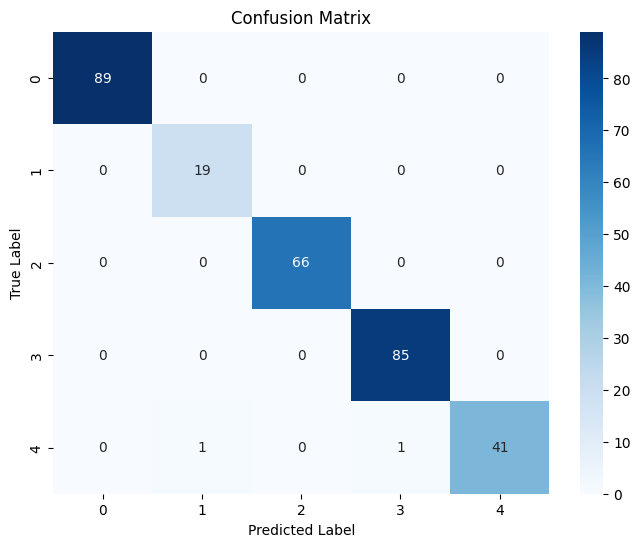

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [1]:

"""train_accuracy = multi_target_rf.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print("Training Accuracy:",train_accuracy)
print("Test Accuracy:", test_accuracy)
# Bar plot of training vs. test accuracy
plt.figure(figsize=(6, 4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_accuracy, test_accuracy], color=['blue', 'green'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Training vs. Test Accuracy")
plt.show()"""


'train_accuracy = multi_target_rf.score(X_train, y_train)\ntest_accuracy = accuracy_score(y_test, y_pred)\nprint("Training Accuracy:",train_accuracy)\nprint("Test Accuracy:", test_accuracy)\n# Bar plot of training vs. test accuracy\nplt.figure(figsize=(6, 4))\nplt.bar([\'Train Accuracy\', \'Test Accuracy\'], [train_accuracy, test_accuracy], color=[\'blue\', \'green\'])\nplt.ylim(0, 1)\nplt.ylabel("Accuracy")\nplt.title("Training vs. Test Accuracy")\nplt.show()'